In [ ]:
import pandas as pd
import json
import numpy as np
import re
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from transformers import pipeline


# Reading the dataset

In [ ]:
filename = 'nikelululemonadidas_tweets.jsonl'

# Read JSONL file with error handling
data = []
with open(filename, 'r', encoding='utf-8') as f:
    for line_num, line in enumerate(f):
        try:
            data.append(json.loads(line))
        except json.JSONDecodeError as e:
            print(f"Skipping line {line_num + 1} due to JSONDecodeError: {e}")
            continue # Skip the problematic line

# Convert to pandas DataFrame for easier analysis
df = pd.DataFrame(data)

# Display first few rows
print(f"Loaded {len(df)} records")
display(df.head())

Loaded 175078 records


,created_at,id,id_str,full_text,truncated,display_text_range,entities,extended_entities,source,in_reply_to_status_id,...,favorited,retweeted,possibly_sensitive,lang,retweeted_status,quoted_status_id,quoted_status_id_str,quoted_status_permalink,quoted_status,withheld_in_countries
0,Fri Oct 01 08:25:03 +0000 2021,1443854459625431000,1443854459625431041,#ad The Nike Women's Air More Uptempo 96 'Whit...,False,"[0, 146]","{'hashtags': [{'text': 'ad', 'indices': [0, 3]...","{'media': [{'id': 1443854458404941800, 'id_str...","<a href=""https://www.hootsuite.com"" rel=""nofol...",NaN,...,False,False,False,en,NaN,NaN,NaN,NaN,NaN,NaN
1,Fri Oct 01 07:37:16 +0000 2021,1443842433641558000,1443842433641558039,@_christiankeith @d1vetsam @KicksFinder They a...,False,"[40, 73]","{'hashtags': [], 'symbols': [], 'user_mentions...",NaN,"<a href=""http://twitter.com/download/iphone"" r...",1.443836e+18,...,False,False,NaN,en,NaN,NaN,NaN,NaN,NaN,NaN
2,Fri Oct 01 10:01:58 +0000 2021,1443878848211439600,1443878848211439632,Proof @LaserShip is stealing. I work from home...,False,"[0, 106]","{'hashtags': [], 'symbols': [], 'user_mentions...","{'media': [{'id': 1443878844923105300, 'id_str...","<a href=""http://twitter.com/download/iphone"" r...",NaN,...,False,False,False,en,NaN,NaN,NaN,NaN,NaN,NaN
3,Fri Oct 01 07:41:45 +0000 2021,1443843563108905000,1443843563108904965,RT @pyleaks: *LEAK ALERT*: The next Supreme x ...,False,"[0, 140]","{'hashtags': [], 'symbols': [], 'user_mentions...",NaN,"<a href=""http://twitter.com/download/android"" ...",NaN,...,False,False,NaN,en,{'created_at': 'Wed Sep 29 15:40:11 +0000 2021...,NaN,NaN,NaN,NaN,NaN
4,Fri Oct 01 06:22:08 +0000 2021,1443823529296867300,1443823529296867350,RT @SneakerScouts: #ad The Space Jam x Nike Le...,False,"[0, 140]","{'hashtags': [{'text': 'ad', 'indices': [19, 2...",NaN,"<a href=""https://mobile.twitter.com"" rel=""nofo...",NaN,...,False,False,NaN,en,{'created_at': 'Thu Sep 30 16:10:08 +0000 2021...,NaN,NaN,NaN,NaN,NaN


In [ ]:
df = df['full_text']
df.head(n = 5)

,full_text
0,#ad The Nike Women's Air More Uptempo 96 'Whit...
1,@_christiankeith @d1vetsam @KicksFinder They a...
2,Proof @LaserShip is stealing. I work from home...
3,RT @pyleaks: *LEAK ALERT*: The next Supreme x ...
4,RT @SneakerScouts: #ad The Space Jam x Nike Le...


# EDA

In [ ]:
print(f"Total tweets: {len(df)}")
print(f"\nNull values in full_text: {df.isnull().sum()}")
print(f"Empty strings: {(df == '').sum()}")
print(f"Duplicate tweets: {df.duplicated().sum()}")
print(f"Unique tweets: {df.nunique()}")

Total tweets: 175078

Null values in full_text: 0
Empty strings: 0
Duplicate tweets: 64177
Unique tweets: 110901


In [ ]:
print(f"Before: {len(df)} tweets")

# Remove duplicates (keeps first occurrence)
df_clean = df.drop_duplicates(keep='first')

# Check after
print(f"After: {len(df_clean)} tweets")

df_clean = pd.DataFrame(df_clean, columns = ['full_text'])

Before: 175078 tweets
After: 110901 tweets


In [ ]:
# Hashtags
df_clean['has_hashtag'] = df_clean['full_text'].str.contains('#', na=False)
df_clean['hashtag_count'] = df_clean['full_text'].str.count('#')
print(f"Tweets with hashtags: {df_clean['has_hashtag'].sum()} ({df_clean['has_hashtag'].mean()*100:.1f}%)")

# Mentions
df_clean['has_mention'] = df_clean['full_text'].str.contains('@', na=False)
df_clean['mention_count'] = df_clean['full_text'].str.count('@')
print(f"Tweets with mentions: {df_clean['has_mention'].sum()} ({df_clean['has_mention'].mean()*100:.1f}%)")

# URLs
df_clean['has_url'] = df_clean['full_text'].str.contains(r'https?://', na=False, regex=True)
df_clean['url_count'] = df_clean['full_text'].str.count(r'https?://')
print(f"Tweets with URLs: {df_clean['has_url'].sum()} ({df_clean['has_url'].mean()*100:.1f}%)")

Tweets with hashtags: 20990 (18.9%)
Tweets with mentions: 104952 (94.6%)
Tweets with URLs: 41217 (37.2%)


In [ ]:
# Emojis (simple detection)
emoji_pattern = re.compile("["
        u"\U0001F600-\U0001F64F"  # emoticons
        u"\U0001F300-\U0001F5FF"  # symbols & pictographs
        u"\U0001F680-\U0001F6FF"  # transport & map symbols
        u"\U0001F1E0-\U0001F1FF"  # flags
        u"\U00002702-\U000027B0"
        u"\U000024C2-\U0001F251"
        "]+", flags=re.UNICODE)

df_clean['has_emoji'] = df_clean.apply(lambda x: bool(emoji_pattern.search(str(x))))
print(f"Tweets with emojis: {df_clean['has_emoji'].sum()} ({df_clean['has_emoji'].mean()*100:.1f}%)")


Tweets with emojis: 0 (nan%)



✓ Saved: twitter_elements.png


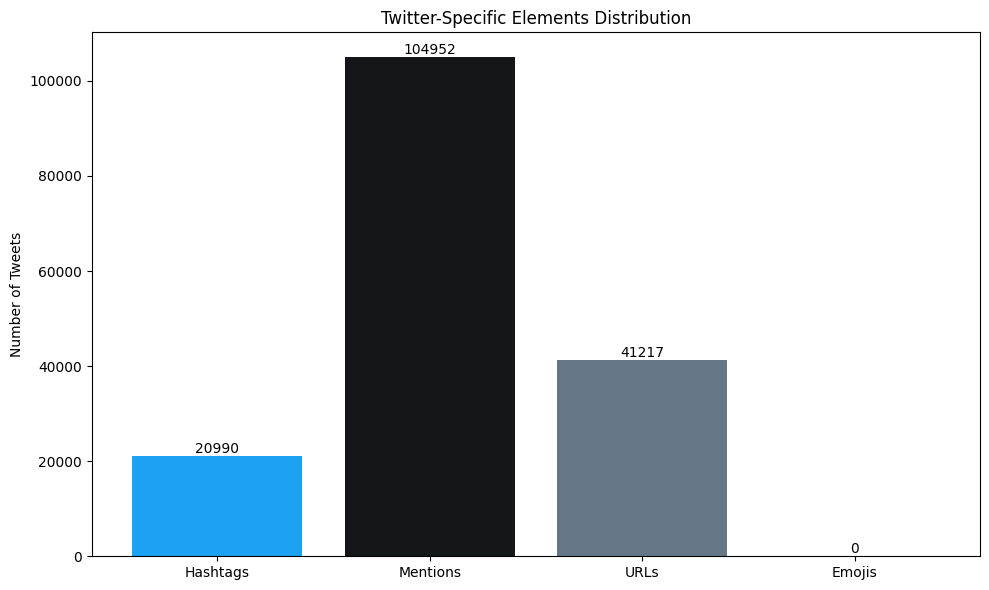

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
elements = ['Hashtags', 'Mentions', 'URLs', 'Emojis']
counts = [df_clean['has_hashtag'].sum(), df_clean['has_mention'].sum(),
          df_clean['has_url'].sum(), df_clean['has_emoji'].sum()]

bars = ax.bar(elements, counts, color=['#1DA1F2', '#14171A', '#657786', '#FFAD1F'])
ax.set_ylabel('Number of Tweets')
ax.set_title('Twitter-Specific Elements Distribution')
ax.bar_label(bars, fmt='%d')

plt.tight_layout()
plt.savefig('twitter_elements.png', dpi=300, bbox_inches='tight')
print("\n✓ Saved: twitter_elements.png")


### TOP HASHTAGS ###

Top 15 hashtags:
 1. #sneakerscouts                  4865 times
 2. #ad                             4669 times
 3. #nike                           1380 times
 4. #snkrs                           841 times
 5. #adidas                          589 times
 6. #kotd                            419 times
 7. #metaverse                       416 times
 8. #nft                             414 times
 9. #running                         363 times
10. #xboxsweepstakes                 358 times
11. #justdoit                        340 times
12. #sneakers                        329 times
13. #giveaway                        300 times
14. #runningshoes                    286 times
15. #sneakerhead                     278 times

✓ Saved: top_hashtags.png


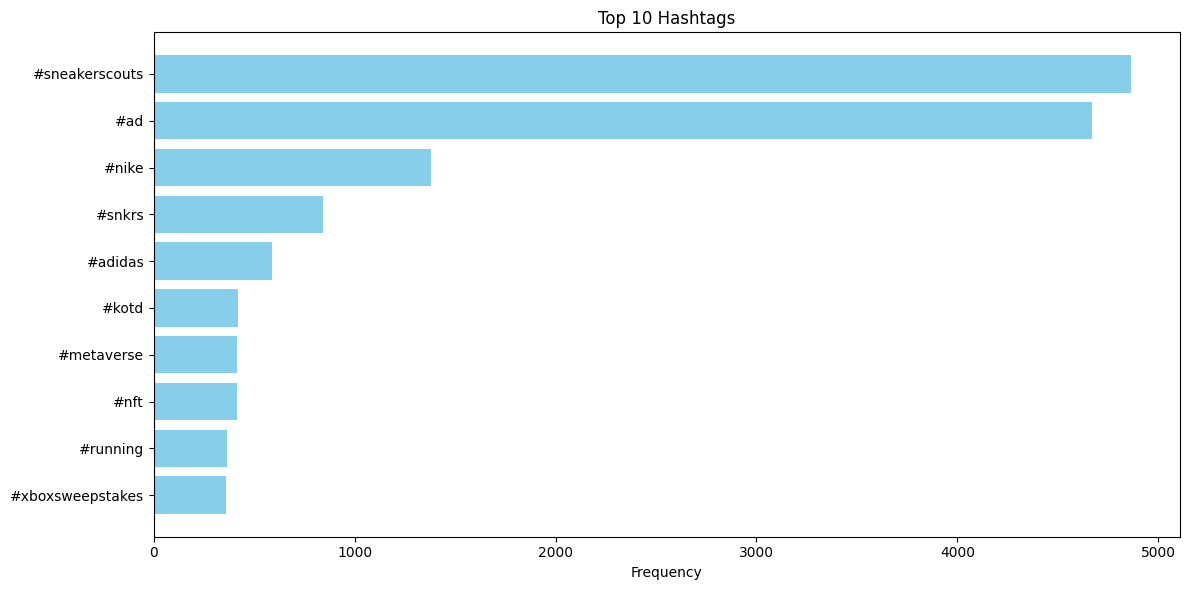

In [ ]:
print("\n### TOP HASHTAGS ###")
all_hashtags = []
for text in df_clean['full_text']:
    hashtags = re.findall(r'#\w+', text.lower())
    all_hashtags.extend(hashtags)

if all_hashtags:
    hashtag_freq = Counter(all_hashtags)
    top_hashtags = hashtag_freq.most_common(15)
    print("\nTop 15 hashtags:")
    for i, (tag, count) in enumerate(top_hashtags, 1):
        print(f"{i:2d}. {tag:30s} {count:5d} times")

    # Visualize top hashtags
    tags, counts = zip(*top_hashtags[:10])
    plt.figure(figsize=(12, 6))
    plt.barh(tags, counts, color='skyblue')
    plt.xlabel('Frequency')
    plt.title('Top 10 Hashtags')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig('top_hashtags.png', dpi=300, bbox_inches='tight')
    print("\n✓ Saved: top_hashtags.png")
else:
    print("No hashtags found in the dataset")


### TOP MENTIONS ###

Top 15 mentions:
 1. @nike                          78478 times
 2. @adidas                        21295 times
 3. @nikestore                      8075 times
 4. @jumpman23                      7569 times
 5. @kingjames                      7486 times
 6. @eneskanter                     7062 times
 7. @lululemon                      5317 times
 8. @austinekeler                   4608 times
 9. @adidasfballus                  4572 times
10. @rtfktstudios                   3612 times
11. @sneakeradmirals                3444 times
12. @finishline                     3046 times
13. @snkr_twitr                     2801 times
14. @adidasoriginals                2216 times
15. @nba                            1570 times

✓ Saved: top_mentions.png


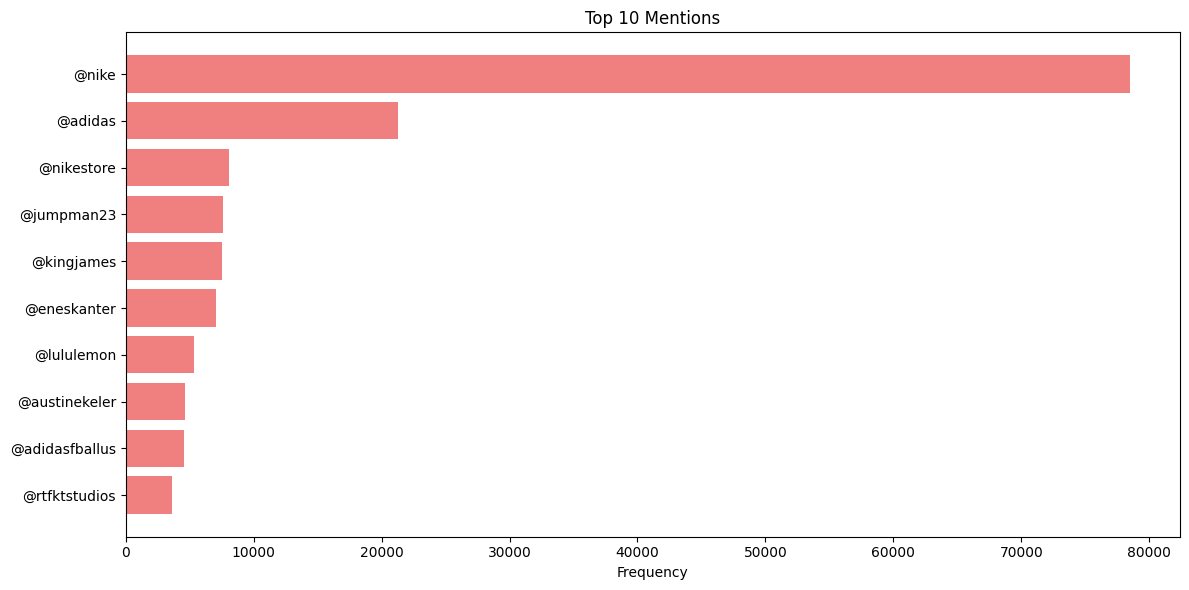

In [ ]:
print("\n### TOP MENTIONS ###")
all_mentions = []
for text in df_clean['full_text']:
    mentions = re.findall(r'@\w+', text.lower())
    all_mentions.extend(mentions)

if all_mentions:
    mention_freq = Counter(all_mentions)       # counter counts items
    top_mentions = mention_freq.most_common(15)
    print("\nTop 15 mentions:")
    for i, (mention, count) in enumerate(top_mentions, 1):
        print(f"{i:2d}. {mention:30s} {count:5d} times")

    # Visualize top mentions
    mentions, counts = zip(*top_mentions[:10])
    plt.figure(figsize=(12, 6))
    plt.barh(mentions, counts, color='lightcoral')
    plt.xlabel('Frequency')
    plt.title('Top 10 Mentions')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig('top_mentions.png', dpi=300, bbox_inches='tight')
    print("\n✓ Saved: top_mentions.png")
else:
    print("No mentions found in the dataset")


In [ ]:
# labelling each tweets with associated brand name

brand_keywords = {
    'Nike': ['nike', 'justdoit', 'swoosh', 'airmax', 'airjordan', 'nikesb', 'nikeair', 'nikewomen', 'nikemen'],
    'Adidas': ['adidas', 'adidasoriginals', 'yeezy', 'ultraboost', 'boost', 'nmd', 'superstar', 'stripes'],
    'Lululemon': ['lululemon', 'lulu', 'lululemonathletics', 'wunderunder', 'alignpant', 'scubahoodie'],
}

def filter_lululemon_tweets(df, text_column='text'):
    """Filter tweets related to Lululemon"""
    lululemon_keywords = [
        'lululemon', 'lulu', 'lululemonathletics', 'wunderunder', 'alignpant', 'scubahoodie' # common misspellings/variations
    ]

    pattern = '|'.join(lululemon_keywords)
    mask = df[text_column].str.contains(pattern, case=False, na=False)

    lulu_df = df[mask].copy()
    print(f"Total tweets: {len(df)}")
    print(f"Lululemon tweets: {len(lulu_df)} ({len(lulu_df)/len(df)*100:.2f}%)")

    return lulu_df


In [ ]:
lulu_df = filter_lululemon_tweets(df_clean, text_column='full_text')

Total tweets: 110901
Lululemon tweets: 5230 (4.72%)


Sentiment Analysis

In [ ]:
def vader_sentiment(text):
    """VADER Sentiment Analysis - Optimized for social media"""
    analyzer = SentimentIntensityAnalyzer()
    scores = analyzer.polarity_scores(text)

    # Classify based on compound score
    if scores['compound'] >= 0.05:
        sentiment = 'positive'
    elif scores['compound'] <= -0.05:
        sentiment = 'negative'
    else:
        sentiment = 'neutral'

    return {
        'vader_compound': scores['compound'],
        'vader_pos': scores['pos'],
        'vader_neu': scores['neu'],
        'vader_neg': scores['neg'],
        'vader_sentiment': sentiment
    }


In [ ]:
sentiment_results = lulu_df['full_text'].apply(vader_sentiment)

# Expand the dictionary results into separate columns in the lulu_df DataFrame
lulu_result_df = pd.concat([lulu_df['full_text'], sentiment_results.apply(pd.Series)], axis=1)

display(lulu_result_df.head())

,full_text,vader_compound,vader_pos,vader_neu,vader_neg,vader_sentiment
74,#FF @LauraMcInnes7 @lululemon @jeffieruth @col...,0.0000,0.000,1.000,0.000,neutral
77,@BillGarlandSpkr @LauraMcInnes7 @lululemon @je...,0.9347,0.328,0.672,0.000,positive
78,RT @Mom_Junky: Leggings can be intimidating! I...,-0.4926,0.000,0.849,0.151,negative
150,@EMRAnswers @ShereeseMayMba @stacy_hurt @Hassa...,0.8402,0.333,0.667,0.000,positive
174,@BillGarlandSpkr @LauraMcInnes7 @lululemon @je...,0.7184,0.214,0.786,0.000,positive


In [ ]:
def analyze_sentiment_results(df):
    """Analyze and display sentiment results"""

    print("\n" + "="*60)
    print("LULULEMON SENTIMENT ANALYSIS RESULTS")
    print("="*60)

    # Overall sentiment distribution
    sentiment_dist = df['vader_sentiment'].value_counts()
    total = len(df)

    print("\nSentiment Distribution:")
    print("-" * 40)
    for sentiment, count in sentiment_dist.items():
        percentage = (count / total) * 100
        print(f"{sentiment.capitalize():12s}: {count:5d} ({percentage:5.2f}%)")

    # Average scores
    print("\n" + "="*60)
    print("AVERAGE SENTIMENT SCORES")
    print("="*60)
    print(f"Compound Score (overall): {df['vader_compound'].mean():.3f}")
    print(f"Positive Score:           {df['vader_pos'].mean():.3f}")
    print(f"Neutral Score:            {df['vader_neu'].mean():.3f}")
    print(f"Negative Score:           {df['vader_neg'].mean():.3f}")

    # Show examples
    print("\n" + "="*60)
    print("SAMPLE POSITIVE TWEETS (Top 3 by compound score)")
    print("="*60)
    positive_tweets = df[df['vader_sentiment'] == 'positive'].nlargest(3, 'vader_compound')
    for idx, row in positive_tweets.iterrows():
        print(f"\n• {row['full_text'][:150]}...") # Changed cleaned_text to full_text
        print(f"  Compound Score: {row['vader_compound']:.3f}")

    print("\n" + "="*60)
    print("SAMPLE NEGATIVE TWEETS (Top 3 by compound score)")
    print("="*60)
    negative_tweets = df[df['vader_sentiment'] == 'negative'].nsmallest(3, 'vader_compound')
    for idx, row in negative_tweets.iterrows():
        print(f"\n• {row['full_text'][:150]}...") # Changed cleaned_text to full_text
        print(f"  Compound Score: {row['vader_compound']:.3f}")

    return sentiment_dist

analyze_sentiment_results(lulu_result_df) # Changed input to the full DataFrame


LULULEMON SENTIMENT ANALYSIS RESULTS

Sentiment Distribution:
----------------------------------------
Positive    :  2607 (49.85%)
Neutral     :  1790 (34.23%)
Negative    :   833 (15.93%)

AVERAGE SENTIMENT SCORES
Compound Score (overall): 0.202
Positive Score:           0.125
Neutral Score:            0.834
Negative Score:           0.041

SAMPLE POSITIVE TWEETS (Top 3 by compound score)

• “It ain’t a force in this world like a focused drive” - Nipsey Hussle. Lastnight was super emotional yo hahaha. Family came out to my “World Of Fantas...
  Compound Score: 0.980

• The weather wasn't ideal but it was fantastic to have so many schools participate in our annual cross-country Invitational. 

Thank you to our support...
  Compound Score: 0.980

• Started the week with family dinner! I am truly blessed to have such an amazing job, be around such incredible talent, and have such wonderful friends...
  Compound Score: 0.979

SAMPLE NEGATIVE TWEETS (Top 3 by compound score)

• @lululemo

,count
vader_sentiment,
positive,2607
neutral,1790
negative,833


In [ ]:
def visualize_sentiment(df, brand_name = 'Lululemon'):
    """Create sentiment visualizations"""

    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle(f'{brand_name} VADER Sentiment Analysis', fontsize=16, fontweight='bold')

    # 1. Sentiment Distribution Bar Chart
    sentiment_counts = df['vader_sentiment'].value_counts()
    colors = {'positive': '#2ecc71', 'neutral': '#95a5a6', 'negative': '#e74c3c'}
    color_list = [colors[sent] for sent in sentiment_counts.index]

    axes[0, 0].bar(sentiment_counts.index, sentiment_counts.values, color=color_list, alpha=0.7, edgecolor='black')
    axes[0, 0].set_title('Sentiment Distribution', fontweight='bold', fontsize=12)
    axes[0, 0].set_ylabel('Number of Tweets', fontsize=10)
    axes[0, 0].set_xlabel('Sentiment', fontsize=10)

    # Add value labels on bars
    for i, v in enumerate(sentiment_counts.values):
        axes[0, 0].text(i, v + (max(sentiment_counts.values) * 0.02),
                        str(v), ha='center', fontweight='bold', fontsize=10)

    # 2. Sentiment Pie Chart
    axes[0, 1].pie(sentiment_counts.values, labels=sentiment_counts.index,
                   autopct='%1.1f%%', colors=[colors[sent] for sent in sentiment_counts.index],
                   startangle=90, textprops={'fontsize': 10, 'fontweight': 'bold'})
    axes[0, 1].set_title('Sentiment Proportion', fontweight='bold', fontsize=12)

    # 3. VADER Compound Score Distribution
    axes[1, 0].hist(df['vader_compound'], bins=50, color='#3498db', alpha=0.7, edgecolor='black')
    axes[1, 0].axvline(df['vader_compound'].mean(), color='red', linestyle='--', linewidth=2,
                       label=f'Mean: {df["vader_compound"].mean():.3f}')
    axes[1, 0].axvline(0, color='gray', linestyle='-', linewidth=1, alpha=0.5)
    axes[1, 0].set_title('VADER Compound Score Distribution', fontweight='bold', fontsize=12)
    axes[1, 0].set_xlabel('Compound Score (-1 to +1)', fontsize=10)
    axes[1, 0].set_ylabel('Frequency', fontsize=10)
    axes[1, 0].legend(fontsize=10)
    axes[1, 0].grid(alpha=0.3)

    # 4. Score Components Comparison
    score_means = {
        'Positive': df['vader_pos'].mean(),
        'Neutral': df['vader_neu'].mean(),
        'Negative': df['vader_neg'].mean()
    }

    colors_comp = ['#2ecc71', '#95a5a6', '#e74c3c']
    bars = axes[1, 1].bar(score_means.keys(), score_means.values(),
                          color=colors_comp, alpha=0.7, edgecolor='black')
    axes[1, 1].set_title('Average Score Components', fontweight='bold', fontsize=12)
    axes[1, 1].set_ylabel('Average Score', fontsize=10)
    axes[1, 1].set_ylim(0, 1)

    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        axes[1, 1].text(bar.get_x() + bar.get_width()/2., height + 0.02,
                        f'{height:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=10)

    plt.tight_layout()
    plt.savefig(f'{brand_name}_vader_sentiment.png', dpi=300, bbox_inches='tight')
    print(f"\n✓ Visualization saved as '{brand_name}_vader_sentiment.png'")
    plt.show()



✓ Visualization saved as 'Lululemon_vader_sentiment.png'


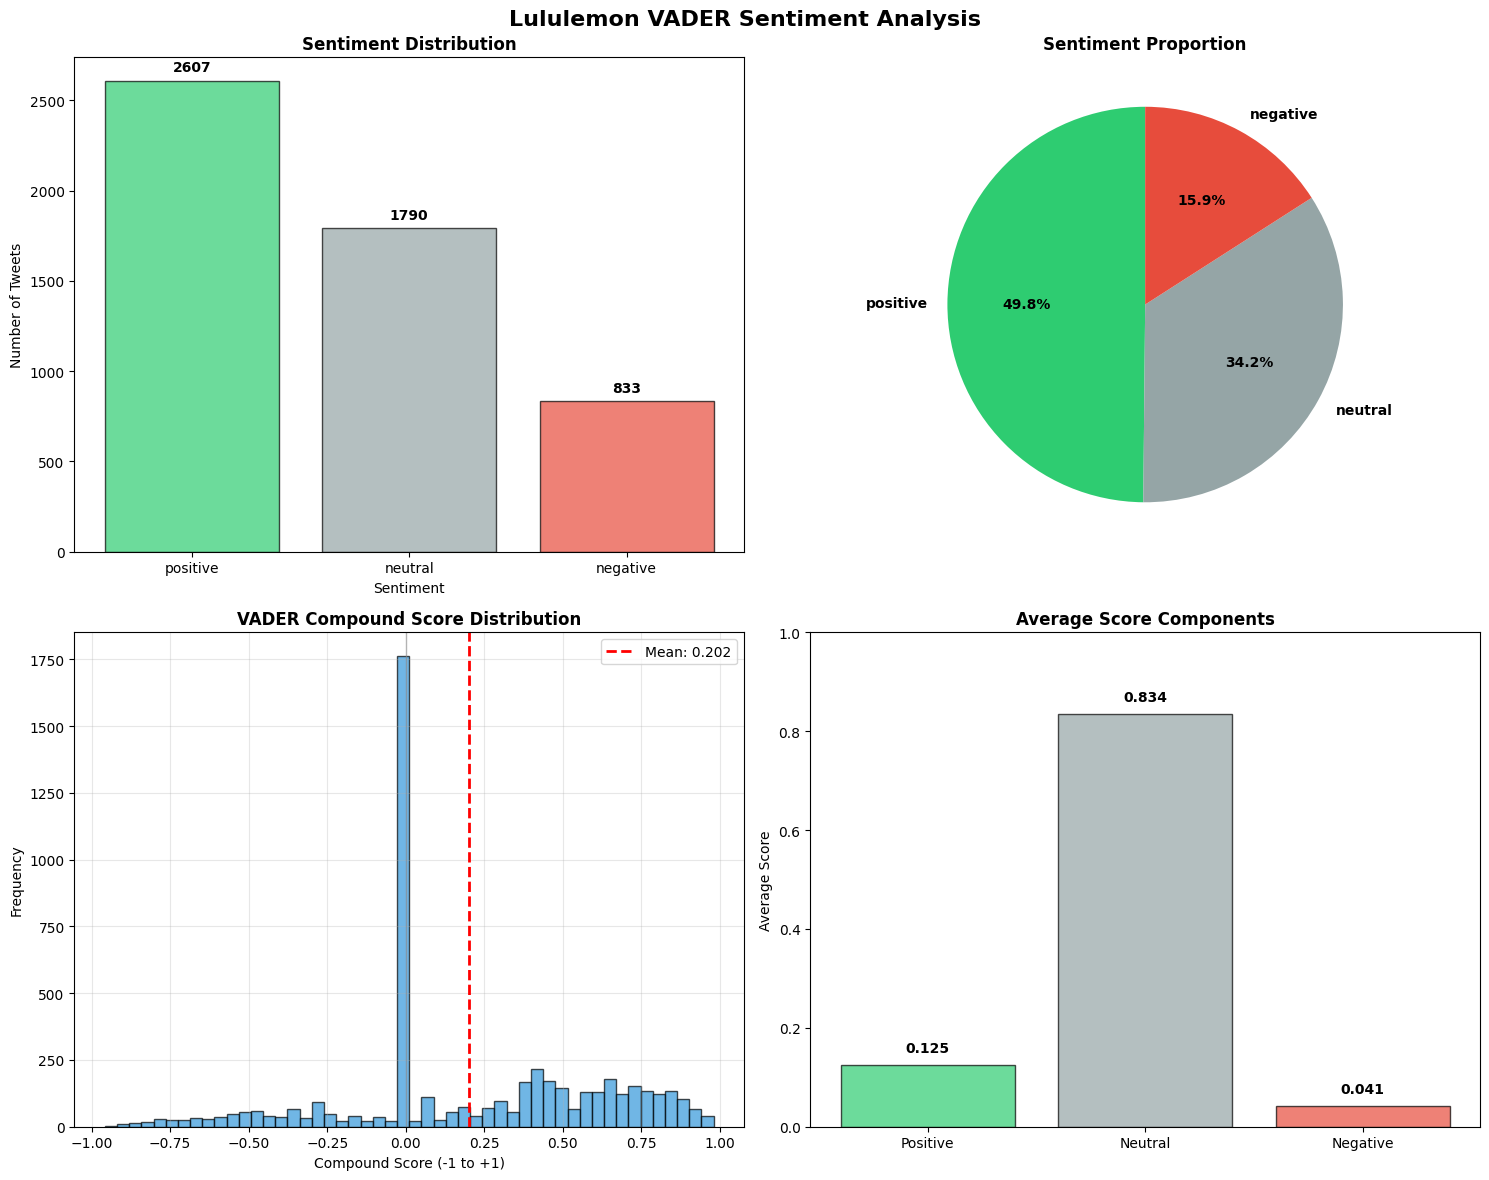

In [ ]:
visualize_sentiment(lulu_result_df)